In [1]:
import NN_model_helper
import numpy as np, pandas as pd, optuna, torch
from sklearn.model_selection import StratifiedKFold
from NN_model import ImprovedNN 
from pathlib import Path
import json, torch
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from NN_model_helper import (evaluate_fold, plot_training_progress, find_optimal_clusters)

import sys
from pathlib import Path


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# classifier/ → MELTING_POINT_2026/
PROJECT_ROOT = Path.cwd().parent        # directory above a path: .../MELTING_POINT_2026

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

processed_dir = PROJECT_ROOT / "data_curation" / "processed_data"

train_path = PROJECT_ROOT / "Ro5" / "artifacts" / "full_train_scaled_no_interaction.parquet"
df_train = pd.read_parquet(train_path)

df_train.head()


,SMILES,MP,Type,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,...,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms,Structure_Cluster
0,ON=Cc1cscc1,122.0,Train,1,-0.239453,-0.811915,-0.247167,-0.670027,-0.593429,-0.041376,...,-0.199183,-0.889538,-0.434742,-0.504875,-0.618592,-0.550322,-0.268728,-0.07374,-0.510997,2
1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,205.5,Train,1,-0.239453,-0.147094,-0.247167,-0.670027,1.554215,1.008411,...,-0.199183,3.464175,-0.434742,4.239993,1.616573,0.429088,-0.268728,-0.07374,-0.147901,5
2,[O-][n+]1ccccc1,64.0,Train,1,-0.239453,-1.079534,-0.247167,-0.670027,-0.815794,0.262521,...,-0.199183,-0.908687,-0.434742,-0.504875,-0.618592,-0.711607,-0.268728,-0.07374,-0.874093,2
3,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,146.0,Train,1,-0.239453,0.883762,-0.247167,-0.670027,3.410957,2.895269,...,-0.199183,3.927528,-0.434742,3.291019,1.616573,-0.903150,-0.268728,-0.07374,-1.237189,5
4,CC(=O)c1ccc(cc1)Br,51.0,Train,1,-0.239453,-0.658299,-0.247167,-0.670027,-0.125061,-0.326855,...,-0.199183,-0.729484,-0.434742,-0.504875,-0.618592,-0.993355,-0.268728,-0.07374,-0.874093,2


In [3]:
# 1) Drop the column "Structure Clusters"
df_train = df_train.drop(columns=["Structure_Cluster"])

# 2) Keep only rows where Ro5 == 1
df_train = df_train[df_train["Ro5"] == 0]

# 3) Reset index (optional but usually a good idea)
df_train = df_train.reset_index(drop=True)

# Quick sanity checks
print(df_train.shape)
print(df_train["Ro5"].value_counts())


(257, 105)
Ro5
0    257
Name: count, dtype: int64


In [4]:
df_train.head()

,SMILES,MP,Type,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,...,RDKit_VSA_EState9,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms
0,N#C/C(=C\c1ccc(cc1)F)/c1nc(c(s1)/N=N/c1c(Br)cc...,171.0,Train,0,3.123529,1.247300,4.045846,-0.670027,-0.165698,0.013278,...,-0.150695,-0.199183,0.164267,-0.434742,-0.504875,-0.618592,0.272086,-0.268728,-0.07374,1.667578
1,OC[C@H]1O[C@]([C@H]([C@@H]1O[C@@H]1O[C@H](CO)[...,175.5,Train,0,-0.239453,0.642113,-0.247167,1.468448,-0.815794,-2.818361,...,-0.150695,-0.199183,0.424527,1.124470,1.393072,-0.618592,3.929674,-0.268728,-0.07374,2.393770
2,BrC(CC1(C(=O)C2(C(C1CC2)(C)C)C)C1(CC(Cc2ccccc2...,215.0,Train,0,-0.239453,1.538568,-0.247167,-0.670027,2.829153,1.123928,...,-0.150695,-0.199183,5.565415,-0.434742,3.291019,-0.618592,-0.506076,-0.268728,-0.07374,-0.147901
3,Clc1nc(Oc2cc(cc(c2)Oc2nc(Cl)nc(n2)Cl)Oc2nc(Cl)...,240.0,Train,0,-0.239453,1.535102,-0.247167,-0.670027,-0.815794,-0.326855,...,-0.150695,-0.199183,0.112650,8.106551,-0.504875,-0.618592,2.621414,-0.268728,-0.07374,4.935441
4,CC(=O)OCC12OC1C(C1C2C(OC=C1)OC1OC(COC(=O)C)C(C...,135.0,Train,0,-0.239453,3.238981,-0.247167,0.755623,1.258615,-1.863942,...,-0.150695,-0.199183,2.794469,2.954683,3.291019,1.616573,4.922787,-0.268728,-0.07374,4.935441


X_scaled shape: (257, 101)
Num features: 101


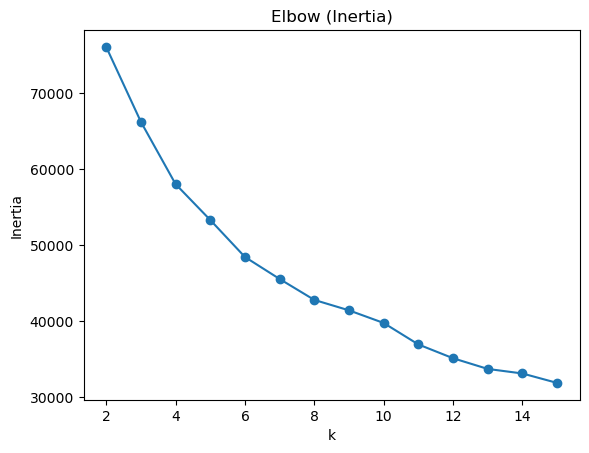

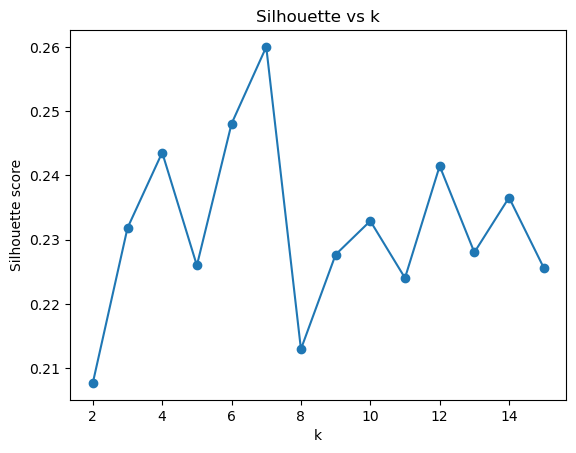

Elbow k: 6
Best silhouette k: 7

✅ Assigned Structure_Cluster with k=6.
                                              SMILES  Structure_Cluster
0  N#C/C(=C\c1ccc(cc1)F)/c1nc(c(s1)/N=N/c1c(Br)cc...                  1
1  OC[C@H]1O[C@]([C@H]([C@@H]1O[C@@H]1O[C@H](CO)[...                  0
2  BrC(CC1(C(=O)C2(C(C1CC2)(C)C)C)C1(CC(Cc2ccccc2...                  1
3  Clc1nc(Oc2cc(cc(c2)Oc2nc(Cl)nc(n2)Cl)Oc2nc(Cl)...                  1
4  CC(=O)OCC12OC1C(C1C2C(OC=C1)OC1OC(COC(=O)C)C(C...                  4
✅ Clustered parquet saved to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/train_scaled_bRo5_no_interaction.parquet


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

BASE = Path.cwd()
artifacts_dir = BASE / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 2) Define feature columns (already scaled)
#    Exclude metadata/labels/non-features
# -----------------------------
exclude = {"SMILES", "MP", "Type", "Ro5"}  # add any other non-features here
num_cols = df_train.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X_scaled = df_train[feature_cols].to_numpy(dtype=np.float32)

print("X_scaled shape:", X_scaled.shape)
print("Num features:", len(feature_cols))

# -----------------------------
# 3) Find optimal k
# -----------------------------
def find_optimal_clusters(X_scaled, max_k=15, random_state=0, plot=True):
    ks = list(range(2, max_k + 1))
    inertias = []
    sils = []

    for k in ks:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=random_state)
        labels = km.fit_predict(X_scaled)

        inertias.append(km.inertia_)
        sils.append(silhouette_score(X_scaled, labels))

    # elbow via kneed (works best when inertia curve is smooth)
    knee = KneeLocator(ks, inertias, curve="convex", direction="decreasing")
    k_elbow = knee.knee

    # silhouette best k
    k_sil = ks[int(np.argmax(sils))]

    if plot:
        plt.figure()
        plt.plot(ks, inertias, marker="o")
        plt.xlabel("k")
        plt.ylabel("Inertia")
        plt.title("Elbow (Inertia)")
        plt.show()

        plt.figure()
        plt.plot(ks, sils, marker="o")
        plt.xlabel("k")
        plt.ylabel("Silhouette score")
        plt.title("Silhouette vs k")
        plt.show()

        print("Elbow k:", k_elbow)
        print("Best silhouette k:", k_sil)

    # pick elbow if available; otherwise silhouette
    return k_elbow if k_elbow is not None else k_sil


random_state = 0
k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)

if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")

# -----------------------------
# 4) Fit final kmeans + assign clusters
# -----------------------------
final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

assert len(cluster_labels) == len(df_train), "Cluster labels length != df rows (mismatch)."

df_clustered = df_train.copy()
df_clustered["Structure_Cluster"] = cluster_labels

print(f"\n✅ Assigned Structure_Cluster with k={k_opt}.")
print(df_clustered[["SMILES", "Structure_Cluster"]].head())

# -----------------------------
# 5) Save clustered parquet (+ optional kmeans)
# -----------------------------
clustered_path = artifacts_dir / "train_scaled_bRo5_no_interaction.parquet"
df_clustered.to_parquet(clustered_path, index=False)
print("✅ Clustered parquet saved to:", clustered_path)


In [6]:
# classifier/ → MELTING_POINT_2026/
PROJECT_ROOT = Path.cwd().parent        # directory above a path: .../MELTING_POINT_2026

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

train_path = PROJECT_ROOT / "Ro5" / "artifacts" / "train_scaled_bRo5_no_interaction.parquet"
df_train = pd.read_parquet(train_path)

df_train.head()

,SMILES,MP,Type,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,...,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms,Structure_Cluster
0,N#C/C(=C\c1ccc(cc1)F)/c1nc(c(s1)/N=N/c1c(Br)cc...,171.0,Train,0,3.123529,1.247300,4.045846,-0.670027,-0.165698,0.013278,...,-0.199183,0.164267,-0.434742,-0.504875,-0.618592,0.272086,-0.268728,-0.07374,1.667578,1
1,OC[C@H]1O[C@]([C@H]([C@@H]1O[C@@H]1O[C@H](CO)[...,175.5,Train,0,-0.239453,0.642113,-0.247167,1.468448,-0.815794,-2.818361,...,-0.199183,0.424527,1.124470,1.393072,-0.618592,3.929674,-0.268728,-0.07374,2.393770,0
2,BrC(CC1(C(=O)C2(C(C1CC2)(C)C)C)C1(CC(Cc2ccccc2...,215.0,Train,0,-0.239453,1.538568,-0.247167,-0.670027,2.829153,1.123928,...,-0.199183,5.565415,-0.434742,3.291019,-0.618592,-0.506076,-0.268728,-0.07374,-0.147901,1
3,Clc1nc(Oc2cc(cc(c2)Oc2nc(Cl)nc(n2)Cl)Oc2nc(Cl)...,240.0,Train,0,-0.239453,1.535102,-0.247167,-0.670027,-0.815794,-0.326855,...,-0.199183,0.112650,8.106551,-0.504875,-0.618592,2.621414,-0.268728,-0.07374,4.935441,1
4,CC(=O)OCC12OC1C(C1C2C(OC=C1)OC1OC(COC(=O)C)C(C...,135.0,Train,0,-0.239453,3.238981,-0.247167,0.755623,1.258615,-1.863942,...,-0.199183,2.794469,2.954683,3.291019,1.616573,4.922787,-0.268728,-0.07374,4.935441,4


In [7]:
TARGET_COL = "MP"

exclude = {"SMILES", TARGET_COL, "Type", "Ro5", "Structure_Cluster"}
num_cols = df_train.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X = df_train[feature_cols].to_numpy(np.float32) 
y = df_train[TARGET_COL].to_numpy(np.float32)
y_strat = df_train["Structure_Cluster"].astype(str).to_numpy()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
folds = [(tr, va) for tr, va in skf.split(X, y_strat)]

print("Total samples:", len(X))
print("Num features:", X.shape[1])
print("Num folds:", len(folds))
print()

for i, (tr_idx, va_idx) in enumerate(folds):
    print(
        f"Fold {i:2d} | "
        f"Train: {len(tr_idx):4d} | "
        f"Val: {len(va_idx):4d}"
    )


Total samples: 257
Num features: 101
Num folds: 10

Fold  0 | Train:  231 | Val:   26
Fold  1 | Train:  231 | Val:   26
Fold  2 | Train:  231 | Val:   26
Fold  3 | Train:  231 | Val:   26
Fold  4 | Train:  231 | Val:   26
Fold  5 | Train:  231 | Val:   26
Fold  6 | Train:  231 | Val:   26
Fold  7 | Train:  232 | Val:   25
Fold  8 | Train:  232 | Val:   25
Fold  9 | Train:  232 | Val:   25


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


In [8]:
import time
import numpy as np
from pathlib import Path

trial_times = []

def objective(trial):
    dropout_rate  = trial.suggest_float("dropout_rate",  0.2, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay  = trial.suggest_float("weight_decay",  1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])

    h1 = trial.suggest_categorical("h1", [64, 96, 128, 160, 192, 224, 256])
    h2 = max(h1 // 2, 4)
    h3 = max(h2 // 2, 2)
    hidden_layers = [h1, h2, h3]

    start = time.perf_counter()
    rmses = []

    for fold_idx, (tr_idx, val_idx) in enumerate(folds):
        X_train_scaled = X[tr_idx]
        y_train        = y[tr_idx]
        X_val_scaled   = X[val_idx]
        y_val          = y[val_idx]

        rmse, *_ = evaluate_fold(
            trial=trial,
            fold_idx=fold_idx,
            X_train_scaled=X_train_scaled,
            y_train=y_train,
            X_val_scaled=X_val_scaled,
            y_val=y_val,
            learning_rate=learning_rate,
            batch_size=batch_size,
            hidden_layers=hidden_layers,
            dropout_rate=dropout_rate,
            weight_decay=weight_decay,
            save_checkpoints=False,
            checkpoint_dir=None,   # <- no checkpoints
        )
        rmses.append(float(rmse))

    elapsed_min = (time.perf_counter() - start) / 60.0
    trial_times.append(elapsed_min)

    avg_rmse = float(np.mean(rmses))

    # Save for later plotting/analysis
    trial.set_user_attr("avg_rmse", avg_rmse)
    trial.set_user_attr("fold_rmses", rmses)
    trial.set_user_attr("elapsed_min", elapsed_min)

    print(f"Trial {trial.number} finished in {elapsed_min:.2f} minutes")
    print(f"Trial {trial.number}: Average RMSE = {avg_rmse:.4f}")

    return avg_rmse

def set_optuna_study(n_trials): 
    start_time = time.perf_counter()
    print("Setting up Optuna study...")
    
    # 1) Set up the Optuna study
    study = optuna.create_study(direction='minimize') #minimize return loss
    study.optimize(objective, n_trials=n_trials)  #CHANGE TO 100 AFTER TESTING
    
    # 2) Identify the best hyperparameters
    best_params = study.best_params #best_params holds the dropout, learning rate, and weight decay that gave the lowest best_val_loss
    print("Best hyperparameters:", best_params)
    
    end_time = time.perf_counter()
    elapsed_time = (end_time - start_time) / 60.0
    print(f"Optuna study completed in {elapsed_time:.2f} minutes")
    
    return best_params, study


device = torch.device("cpu")
best_params, study = set_optuna_study(n_trials=20)

[I 2026-02-09 21:25:20,254] A new study created in memory with name: no-name-8f9397bd-2862-462f-849a-49263f17f251


Setting up Optuna study...
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 181.3962 | Val Loss: 181.1342 | ES 0/30
[Fold 0] Early stopping  at epoch 31 (best Val Loss: 181.1342)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 185.0949 | Val Loss: 176.9184 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 184.4777 | Val Loss: 176.4397 | ES 14/30
[Fold 1] Early stopping  at epoch 66 (best Val Loss: 176.3399)
Fold 2: Training on cpu
[Fold 2] Epoch    1 | Train Loss: 185.2584 | Val Loss: 172.0270 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 185.4503 | Val Loss: 171.5344 | ES 2/30
[Fold 2] Epoch  100 | Train Loss: 184.4745 | Val Loss: 171.5403 | ES 22/30
[Fold 2] Early stopping  at epoch 108 (best Val Loss: 171.4941)
Fold 3: Training on cpu
[Fold 3] Epoch    1 | Train Loss: 180.1970 | Val Loss: 208.6492 | ES 0/30
[Fold 3] Early stopping  at epoch 31 (best Val Loss: 208.6492)
Fold 4: Training on cpu
[Fold 4] Epoch    1 | Train Loss: 181.2398 | Val Loss: 201.5211 | ES 0/30
[Fold 

[I 2026-02-09 21:25:25,294] Trial 0 finished with value: 181.90560607910157 and parameters: {'dropout_rate': 0.3535051464491084, 'learning_rate': 2.1279621567120196e-05, 'weight_decay': 4.453241356076334e-06, 'batch_size': 32, 'h1': 64}. Best is trial 0 with value: 181.90560607910157.


[Fold 9] Epoch  100 | Train Loss: 183.6666 | Val Loss: 156.6926 | ES 6/30
[Fold 9] Early stopping  at epoch 124 (best Val Loss: 156.6258)
Trial 0 finished in 0.08 minutes
Trial 0: Average RMSE = 181.9056
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 186.0513 | Val Loss: 180.3247 | ES 0/30
[Fold 0] Early stopping  at epoch 31 (best Val Loss: 180.3247)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 186.6926 | Val Loss: 175.9881 | ES 0/30
[Fold 1] Early stopping  at epoch 31 (best Val Loss: 175.9881)
Fold 2: Training on cpu
[Fold 2] Epoch    1 | Train Loss: 182.0928 | Val Loss: 171.4731 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 180.8389 | Val Loss: 171.1799 | ES 12/30
[Fold 2] Early stopping  at epoch 68 (best Val Loss: 171.1234)
Fold 3: Training on cpu
[Fold 3] Epoch    1 | Train Loss: 180.2806 | Val Loss: 208.4426 | ES 0/30
[Fold 3] Early stopping  at epoch 31 (best Val Loss: 208.4426)
Fold 4: Training on cpu
[Fold 4] Epoch    1 | Train Loss: 180.3722 | Val Loss

[I 2026-02-09 21:25:27,112] Trial 1 finished with value: 181.5888671875 and parameters: {'dropout_rate': 0.4932828430185634, 'learning_rate': 1.3446865168735239e-05, 'weight_decay': 0.0009263701197903118, 'batch_size': 64, 'h1': 128}. Best is trial 1 with value: 181.5888671875.


...

[Fold 9] Early stopping  at epoch 420 (best Val Loss: 71.5059)
Trial 17 finished in 1.15 minutes
Trial 17: Average RMSE = 86.2532
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 183.5160 | Val Loss: 180.9312 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 179.0585 | Val Loss: 179.4387 | ES 0/30
[Fold 0] Epoch  100 | Train Loss: 177.5579 | Val Loss: 177.0815 | ES 0/30
[Fold 0] Epoch  150 | Train Loss: 175.3850 | Val Loss: 174.6438 | ES 0/30
[Fold 0] Epoch  200 | Train Loss: 171.9419 | Val Loss: 172.1306 | ES 6/30
[Fold 0] Epoch  250 | Train Loss: 171.2161 | Val Loss: 171.1400 | ES 19/30
[Fold 0] Early stopping  at epoch 261 (best Val Loss: 170.3677)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 183.5977 | Val Loss: 180.0706 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 181.4127 | Val Loss: 178.8715 | ES 3/30
[Fold 1] Epoch  100 | Train Loss: 179.6857 | Val Loss: 176.8427 | ES 3/30
[Fold 1] Epoch  150 | Train Loss: 175.0799 | Val Loss: 174.5857 | ES 0/30
[Fold 1] Epoch  2

[I 2026-02-09 21:33:59,388] Trial 18 finished with value: 170.9808090209961 and parameters: {'dropout_rate': 0.30326798858051496, 'learning_rate': 7.025635915721307e-05, 'weight_decay': 1.3452355491209058e-06, 'batch_size': 16, 'h1': 256}. Best is trial 16 with value: 47.312479400634764.


[Fold 9] Early stopping  at epoch 271 (best Val Loss: 149.0899)
Trial 18 finished in 0.74 minutes
Trial 18: Average RMSE = 170.9808
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 183.9098 | Val Loss: 180.0394 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 176.1541 | Val Loss: 179.6387 | ES 0/30
[Fold 0] Epoch  100 | Train Loss: 180.9227 | Val Loss: 178.9392 | ES 2/30
[Fold 0] Epoch  150 | Train Loss: 176.3645 | Val Loss: 178.2303 | ES 2/30
[Fold 0] Epoch  200 | Train Loss: 181.3015 | Val Loss: 178.0307 | ES 5/30
[Fold 0] Epoch  250 | Train Loss: 181.3752 | Val Loss: 177.9802 | ES 16/30
[Fold 0] Epoch  300 | Train Loss: 177.8500 | Val Loss: 177.9322 | ES 23/30
[Fold 0] Early stopping  at epoch 307 (best Val Loss: 177.6773)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 182.0285 | Val Loss: 176.0926 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 178.9952 | Val Loss: 172.6832 | ES 0/30
[Fold 1] Epoch  100 | Train Loss: 172.2458 | Val Loss: 169.0614 | ES 0/30
[Fold 1] Epoch

[I 2026-02-09 21:34:44,884] Trial 19 finished with value: 143.65475769042968 and parameters: {'dropout_rate': 0.2774273891157973, 'learning_rate': 0.0005090353500437357, 'weight_decay': 2.0729447162261477e-05, 'batch_size': 64, 'h1': 256}. Best is trial 16 with value: 47.312479400634764.


[Fold 9] Early stopping  at epoch 485 (best Val Loss: 131.4451)
Trial 19 finished in 0.76 minutes
Trial 19: Average RMSE = 143.6548
Best hyperparameters: {'dropout_rate': 0.22900198495119897, 'learning_rate': 0.0009883768987704834, 'weight_decay': 2.2361058285978367e-05, 'batch_size': 16, 'h1': 256}
Optuna study completed in 9.41 minutes


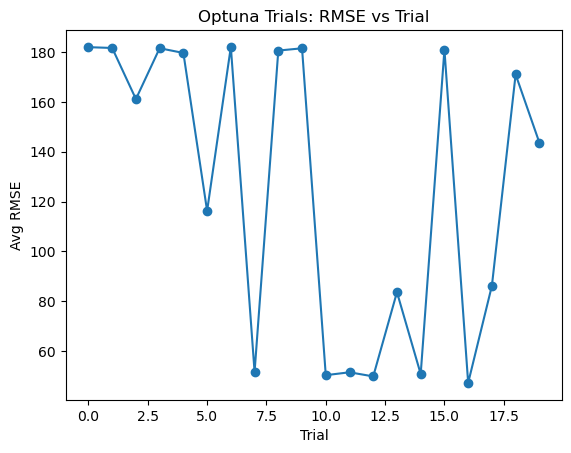

In [9]:
import matplotlib.pyplot as plt

df_trials = study.trials_dataframe(attrs=("number", "value", "user_attrs"))
rmse_by_trial = df_trials["value"].to_numpy()   # value == returned avg_rmse
trial_nums = df_trials["number"].to_numpy()

plt.figure()
plt.plot(trial_nums, rmse_by_trial, marker="o")
plt.xlabel("Trial")
plt.ylabel("Avg RMSE")
plt.title("Optuna Trials: RMSE vs Trial")
plt.show()


In [10]:
# Save the best parameters

print("Best Trial Number:", study.best_trial.number)
print("  RMSE:", study.best_value)
print("  Params:", study.best_params)

Best Trial Number: 16
  RMSE: 47.312479400634764
  Params: {'dropout_rate': 0.22900198495119897, 'learning_rate': 0.0009883768987704834, 'weight_decay': 2.2361058285978367e-05, 'batch_size': 16, 'h1': 256}


In [11]:
from pathlib import Path
import torch
import pandas as pd

# BASE and artifacts_dir should already be defined (same script as before)
BASE = Path.cwd()  # Ro5
artifacts_dir = BASE / "artifacts"

# ---------- Directories for final best models + checkpoints ----------
best_models_dir = artifacts_dir / "bRo5_best_models_no_interaction"
best_models_dir.mkdir(parents=True, exist_ok=True)

final_ckpt_dir = BASE / "checkpoints_bRo5_best_no_interaction"
final_ckpt_dir.mkdir(parents=True, exist_ok=True)

# Make sure best_params exists (from your Optuna study: best_params, study = set_optuna_study(...))
print("Best hyperparameters from Optuna:", best_params)

# Helper to derive hidden layers from best_params (same logic as in objective)
def build_hidden_layers_from_best(best_params):
    h1 = best_params["h1"]
    h2 = max(h1 // 2, 4)
    h3 = max(h2 // 2, 2)
    return [h1, h2, h3]

hidden_layers = build_hidden_layers_from_best(best_params)
dropout_rate  = best_params["dropout_rate"]
learning_rate = best_params["learning_rate"]
weight_decay  = best_params["weight_decay"]
batch_size    = best_params["batch_size"]

print("Using hidden_layers:", hidden_layers)
print("dropout:", dropout_rate, "| lr:", learning_rate, "| wd:", weight_decay, "| batch_size:", batch_size)

# To keep track of metrics across folds
final_fold_metrics = []

# ---------- Final training loop for all folds (using `folds`, X, y) ----------
# Assumes you already defined:
#   X, y, folds = [(tr_idx, val_idx), ...] earlier (same as in `objective`)
for fold_idx, (tr_idx, val_idx) in enumerate(folds):
    print(f"\n==================== Final training for fold {fold_idx} ====================")

    # Slice the global X, y using the same folds as during Optuna
    X_train_scaled = X[tr_idx]
    y_train        = y[tr_idx]
    X_val_scaled   = X[val_idx]
    y_val          = y[val_idx]

    # Train this fold with the best hyperparameters
    rmse, r2, q2, model, train_losses, val_losses, stop_epoch = evaluate_fold(
        trial=None,                    # not needed for final run
        fold_idx=fold_idx,
        X_train_scaled=X_train_scaled,
        y_train=y_train,
        X_val_scaled=X_val_scaled,
        y_val=y_val,
        hidden_layers=hidden_layers,
        learning_rate=learning_rate,
        batch_size=batch_size,
        dropout_rate=dropout_rate,
        weight_decay=weight_decay,
        max_epochs=10**9,              # will stop via early-stopping anyway
        patience=30,
        min_delta=0.0,
        save_checkpoints=True,         # save checkpoints for this BEST config
        checkpoint_dir=final_ckpt_dir, # root; evaluate_fold will create fold_{k}/ inside
        save_every_n_epochs=15
    )

    # ---------- Save the final (best) model for this fold ----------
    model_path = best_models_dir / f"Ro5_best_fold_{fold_idx}.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "hidden_layers": hidden_layers,
            "dropout_rate": dropout_rate,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "fold_idx": fold_idx,
            "rmse": rmse,
            "r2": r2,
            "q2": q2,
        },
        model_path,
    )
    print(f"[Fold {fold_idx}] Saved best model to: {model_path}")

    # store metrics
    final_fold_metrics.append(
        {
            "Fold": fold_idx,
            "RMSE": rmse,
            "R2": r2,
            "Q2": q2,
            "Stop_Epoch": stop_epoch,
            "Model_Path": str(model_path),
        }
    )

# ---------- Save a summary CSV of all folds ----------
metrics_df = pd.DataFrame(final_fold_metrics)
metrics_path = best_models_dir / "bRo5_best_models_no_interaction_summary.csv"
metrics_df.to_csv(metrics_path, index=False)
print("\n✅ Saved summary of best models across folds to:", metrics_path)
print(metrics_df)


Best hyperparameters from Optuna: {'dropout_rate': 0.22900198495119897, 'learning_rate': 0.0009883768987704834, 'weight_decay': 2.2361058285978367e-05, 'batch_size': 16, 'h1': 256}
Using hidden_layers: [256, 128, 64]
dropout: 0.22900198495119897 | lr: 0.0009883768987704834 | wd: 2.2361058285978367e-05 | batch_size: 16

==================== Final training for fold 0 ====================
Fold 0: Training on cpu
Checkpoints will be saved to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/checkpoints_bRo5_best_no_interaction/fold_0
[Fold 0] Regular checkpoint saved at epoch 1 - RMSE: 180.6938
[Fold 0] Epoch    1 | Train Loss: 182.6411 | Val Loss: 180.9171 | ES 0/30
[Fold 0] Regular checkpoint saved at epoch 15 - RMSE: 169.9577
[Fold 0] Regular checkpoint saved at epoch 30 - RMSE: 151.1142
[Fold 0] Regular checkpoint saved at epoch 45 - RMSE: 131.7301
[Fold 0] Epoch   50 | Train Loss: 124.3678 | Val Loss: 121.1923 | ES 0/30
[Fold 0] Regular checkpoint saved at epoch 60 - RMSE: 111.7

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/bRo5_best_models_no_interaction/Ro5_best_fold_2.pt"

TEST_SCALED = BASE / "artifacts/full_test_scaled_no_interaction.parquet"   
OUT_PRED_CSV = BASE / "artifacts/test_bRo5_predictions_no_interaction.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE = 0.22900198495119897 # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 101

=== TEST METRICS ===
RMSE: 76.0962
MAE : 63.2904
R^2 : -0.1427

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_bRo5_predictions_no_interaction.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61367/3850043538.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [18]:
import pandas as pd
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_bRo5_predictions_no_interaction.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 76.096
RMSE (Ro5): 76.512
RMSE (bRo5): 53.584


In [7]:
from pathlib import Path
import torch
import pandas as pd

# BASE and artifacts_dir should already be defined (same script as before)
BASE = Path.cwd()  # Ro5
artifacts_dir = BASE / "artifacts"

# ---------- Directories for final best models + checkpoints ----------
best_models_dir = artifacts_dir / "Ro5_best_models"
best_models_dir.mkdir(parents=True, exist_ok=True)

final_ckpt_dir = BASE / "checkpoints_Ro5_best"
final_ckpt_dir.mkdir(parents=True, exist_ok=True)

# Make sure best_params exists (from your Optuna study: best_params, study = set_optuna_study(...))
print("Best hyperparameters from Optuna:", best_params)

# Helper to derive hidden layers from best_params (same logic as in objective)
def build_hidden_layers_from_best(best_params):
    h1 = best_params["h1"]
    h2 = max(h1 // 2, 4)
    h3 = max(h2 // 2, 2)
    return [h1, h2, h3]

hidden_layers = build_hidden_layers_from_best(best_params)
dropout_rate  = best_params["dropout_rate"]
learning_rate = best_params["learning_rate"]
weight_decay  = best_params["weight_decay"]
batch_size    = best_params["batch_size"]

print("Using hidden_layers:", hidden_layers)
print("dropout:", dropout_rate, "| lr:", learning_rate, "| wd:", weight_decay, "| batch_size:", batch_size)

# To keep track of metrics across folds
final_fold_metrics = []

# ---------- Final training loop for all folds (using `folds`, X, y) ----------
# Assumes you already defined:
#   X, y, folds = [(tr_idx, val_idx), ...] earlier (same as in `objective`)
for fold_idx, (tr_idx, val_idx) in enumerate(folds):
    print(f"\n==================== Final training for fold {fold_idx} ====================")

    # Slice the global X, y using the same folds as during Optuna
    X_train_scaled = X[tr_idx]
    y_train        = y[tr_idx]
    X_val_scaled   = X[val_idx]
    y_val          = y[val_idx]

    # Train this fold with the best hyperparameters
    rmse, r2, q2, model, train_losses, val_losses, stop_epoch = evaluate_fold(
        trial=None,                    # not needed for final run
        fold_idx=fold_idx,
        X_train_scaled=X_train_scaled,
        y_train=y_train,
        X_val_scaled=X_val_scaled,
        y_val=y_val,
        hidden_layers=hidden_layers,
        learning_rate=learning_rate,
        batch_size=batch_size,
        dropout_rate=dropout_rate,
        weight_decay=weight_decay,
        max_epochs=10**9,              # will stop via early-stopping anyway
        patience=30,
        min_delta=0.0,
        save_checkpoints=True,         # save checkpoints for this BEST config
        checkpoint_dir=final_ckpt_dir, # root; evaluate_fold will create fold_{k}/ inside
        save_every_n_epochs=15
    )

    # ---------- Save the final (best) model for this fold ----------
    model_path = best_models_dir / f"Ro5_best_fold_{fold_idx}.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "hidden_layers": hidden_layers,
            "dropout_rate": dropout_rate,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "fold_idx": fold_idx,
            "rmse": rmse,
            "r2": r2,
            "q2": q2,
        },
        model_path,
    )
    print(f"[Fold {fold_idx}] Saved best model to: {model_path}")

    # store metrics
    final_fold_metrics.append(
        {
            "Fold": fold_idx,
            "RMSE": rmse,
            "R2": r2,
            "Q2": q2,
            "Stop_Epoch": stop_epoch,
            "Model_Path": str(model_path),
        }
    )

# ---------- Save a summary CSV of all folds ----------
metrics_df = pd.DataFrame(final_fold_metrics)
metrics_path = best_models_dir / "Ro5_best_models_summary.csv"
metrics_df.to_csv(metrics_path, index=False)
print("\n✅ Saved summary of best models across folds to:", metrics_path)
print(metrics_df)


Best hyperparameters from Optuna: {'dropout_rate': 0.31955324794371087, 'learning_rate': 0.0009934816492230985, 'weight_decay': 0.000527732646389566, 'batch_size': 32, 'h1': 224}
Using hidden_layers: [224, 112, 56]
dropout: 0.31955324794371087 | lr: 0.0009934816492230985 | wd: 0.000527732646389566 | batch_size: 32

==================== Final training for fold 0 ====================
Fold 0: Training on cpu
Checkpoints will be saved to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/checkpoints_Ro5_best/fold_0
[Fold 0] Regular checkpoint saved at epoch 1 - RMSE: 126.3652
[Fold 0] Epoch    1 | Train Loss: 135.6386 | Val Loss: 125.8903 | ES 0/30
[Fold 0] Regular checkpoint saved at epoch 15 - RMSE: 39.0390
[Fold 0] Regular checkpoint saved at epoch 30 - RMSE: 37.7536
[Fold 0] Regular checkpoint saved at epoch 45 - RMSE: 37.8773
[Fold 0] Epoch   50 | Train Loss: 37.1482 | Val Loss: 37.1477 | ES 6/30
[Fold 0] Regular checkpoint saved at epoch 60 - RMSE: 37.0553
[Fold 0] Regular check

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/Ro5_best_models/Ro5_best_fold_9.pt"

TEST_SCALED = BASE / "artifacts/df_test_scaled.parquet"   
OUT_PRED_CSV = BASE / "artifacts/test_Ro5_predictions.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.31955324794371087  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 118

=== TEST METRICS ===
RMSE: 37.3960
MAE : 27.8679
R^2 : 0.7240

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_Ro5_predictions.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_43306/3641735044.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [ ]:
# Plotting optuna trial with RMSE

import matplotlib.pyplot as plt
import pandas as pd

# Collect data from your study
records = []
for t in study.trials:
    if t.value is not None:  # skip failed/pruned trials
        records.append({"trial": t.number, "rmse": t.value})

df = pd.DataFrame(records)

plt.figure(figsize=(8,5))
plt.plot(df["trial"], df["rmse"], marker="o")
plt.title("Optuna Trials vs Mean RMSE (10-Fold Average)")
plt.xlabel("Trial Number")
plt.ylabel("Average RMSE")
plt.grid(True)
plt.show()

In [ ]:
# For Each trial, save the model for each fold?
# when saving checkpoints, is it saving the whole model?
# differenc between epochs saving and the model saving



In [ ]:
# Load the best model (best trial, best fold)


# Grab the test data and run it